---
# AmesPAHdbPythonSuite Exercises

In the following exercises we will: 
1) Examine results from the previous fit, find the most contributing PAHs, and inspect their properties.
2) Perform a new fit using a different modeling configuration.
3) Compare results between the two fits.


---
### Exercise 1

1) Parse the database.
2) Load the 'PAHdb_PurePAHs_cascade_7eV_fit.pkl' generated from the demo (also provided in the exercise directory).
3) Obtain the UIDs of the 5 most contributing PAHs. 
4) What is the charge state, size, and formula of those PAHs?
5) Examine the PAHs geometry.
---

Parse the database

In [75]:
import pickle

from amespahdbpythonsuite.amespahdb import AmesPAHdb
from amespahdbpythonsuite import observation

# Database file
xml = 'pahdb-complete-theoretical-v4.00-alpha.xml'

# Parse database 
pahdb = AmesPAHdb(filename=xml, cache=True)


                 AmesPAHdbPythonSuite
                 
                          by
                          
                Dr. Christiaan Boersma
                
                          and
                         
             Dr. Alexandros Maragkoudakis
             
               Dr. Matthew J. Shannanon
               
                  Dr. Joseph E. Roser
                 

          SUITE VERSION: 0.5.0.post77+ge1dfed1         

                  CHECKING FOR UPDATE                  

                  NO UPDATE AVAILABLE                  

           WEBSITE: WWW.ASTROCHEM.ORG/PAHDB/           

          CONTACT: CHRISTIAAN.BOERSMA@NASA.GOV         

             RESTORING DATABASE FROM CACHE             

==
FILENAME                    : /var/folders/45/x25kzx515kd28plk4n3_gy0r0000gp/T/a4dc541fbf033c4cf55e510c874ed3a3.pkl
ORIGNINAL FILENAME          : pahdb-complete-theoretical-v4.00-alpha.xml
PARSE TIME                  : 0:00:01.520207
DATABASE                    

Load PAHdb fit pickle and select the first 5 most contributing PAHs

In [76]:
# Load PAHdb fit pickle
pahdbfit = pickle.load(open('PAHdb_PDRs4All_MIRI-MRS_APDR_Template_fit-PAHs.pkl', 'rb'))

# Select first 5 most contributing PAHs
top_uids = list(pahdbfit.keys())[:5]
print(top_uids)

[9578, 6328, 10542, 10550, 10823]


Get and examine the PAH species properties

In [77]:
# Get species and print properties
pahs = pahdb.getspeciesbyuid(top_uids)
pahs.print()

FORMULA   : C94H26
CHARGE    : 0
SYMMETRY  : 1-AG
WEIGHT    : 1154.20345
TOTAL_E   : -3598.35566535
VIB_E     : 546.1129
METHOD    : RB3LYP
N_SOLO    : 10
N_DUO     : 16
N_TRIO    : 0
N_QUARTET : 0
N_QUINTET : 0
N_CH2     : 0
N_CHX     : 0
N_C       : 94
N_H       : 26
N_N       : 0
N_O       : 0
N_MG      : 0
N_SI      : 0
N_FE      : 0
COMMENT   : # b3lyp/6-31G* freq guess=check geom=check int=grid=ultrafine
FORMULA   : C150H36+2
CHARGE    : 2
SYMMETRY  : 3-A
WEIGHT    : 1836.2817
TOTAL_E   : -5731.05199446
VIB_E     : 825.473
METHOD    : UBP86
N_SOLO    : 0
N_DUO     : 18
N_TRIO    : 18
N_QUARTET : 0
N_QUINTET : 0
N_CH2     : 0
N_CHX     : 0
N_C       : 150
N_H       : 36
N_N       : 0
N_O       : 0
N_MG      : 0
N_SI      : 0
N_FE      : 0
COMMENT   : #bp86/4-31G freq guess=check geom=check scf=(xqc,MaxConventional=64,m xcycles=128)
FORMULA   : C54H20+
CHARGE    : 1
SYMMETRY  : 2-A"
WEIGHT    : 668.1565
TOTAL_E   : -2069.89467264
VIB_E     : 348.9947
METHOD    : UB3LYP
N_SOLO    : 

Plot their geometries

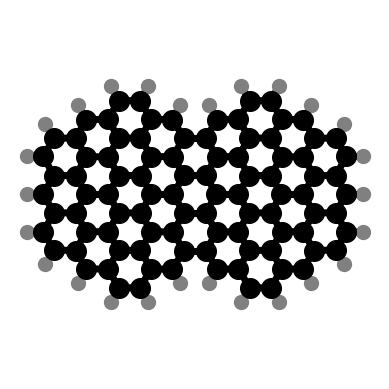

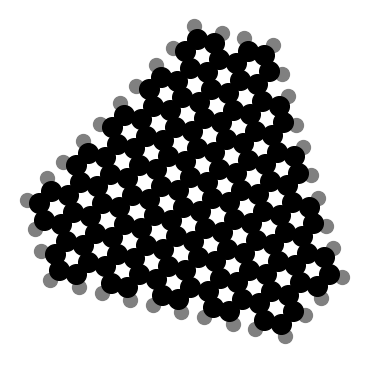

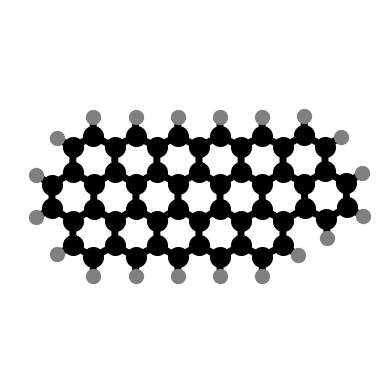

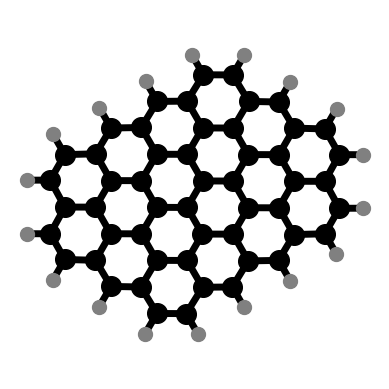

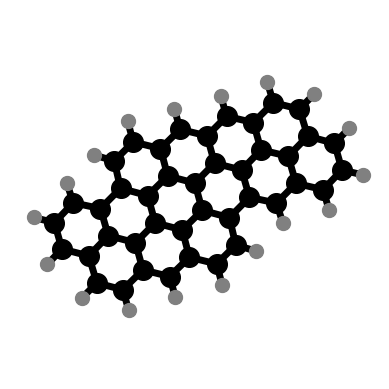

In [78]:
# Plot geometry
geometry = pahdb.getgeometrybyuid(top_uids)
geometry.diagonalize()
for uid in top_uids:
    geometry.plot(uid)

---
### Exercise 2

1) Read the obserevations file and convert to wavenumber (1/cm) units.
2) Select PAHs for fitting.
3) Load the provided transitions object pickle which contains the 7 eV PAH spectra.
4) Create new spectrum object with convolved Gaussian profiles with a FWHM = 10 /cml.
5) Fit the observations.
6) Plot the results.
---

Read the observations file and convert to wavenumber (1/cm) units.

In [89]:
# Create observations object
specfile = 'PDRs4All_MIRI-MRS_APDR_Template.ipac'
obs = observation.Observation(specfile)

# Convert to wavenumber.
obs.abscissaunitsto("1/cm")

Select PAHs for fitting

In [83]:
# Select PAHs
uids = pahdb.search(
    'magnesium=0 oxygen=0 iron=0 silicium=0 nitrogen=0 chx=0 ch2=0 c>20 hydrogen>0'
)
# Include fullerenes
fullerenes = [717, 720, 723, 735, 736, 737]

# Update uids
uids = uids + fullerenes

Apply cascade emission model, create PAHs emission spectra

In [81]:
from amespahdbpythonsuite.transitions import Transitions
# Load transitions pickle
trans_pkl = pickle.load(open('PAHdb_PurePAHs_cascade_7eV_transitions.pkl', 'rb'))

# Create transitions object
transitions = Transitions(trans_pkl, pahdb=pahdb.getdatabaseref())

# Convolve the bands using Gaussian profile with FWHM of 10 /cm 
spectrum = transitions.convolve(
    grid=obs.getgrid(), fwhm=10.0, gaussian=True, multiprocessing=True
)

              USING GAUSSIAN LINE PROFILES             

  GRID: (XMIN,XMAX)=(666.677, 1818.137); 19959 POINTS  

                     FWHM: 10.0 /cm                    

           USING MULTIPROCESSING WITH 9 CORES          



Fit the spectrum

In [82]:
fit = spectrum.fit(obs, multiprocessing=True, notice=False)

Plot results

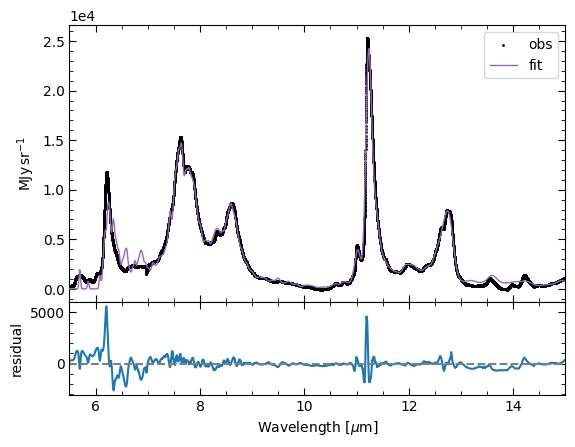

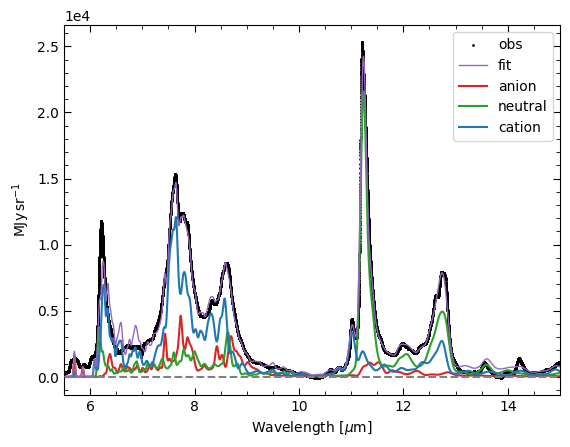

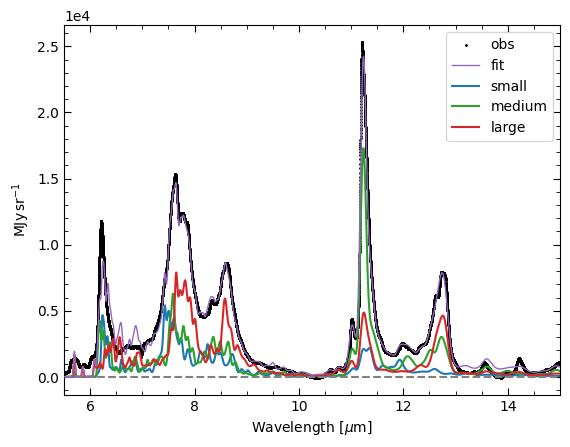

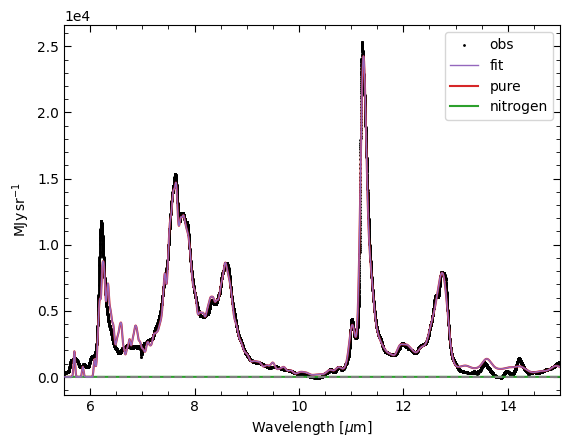

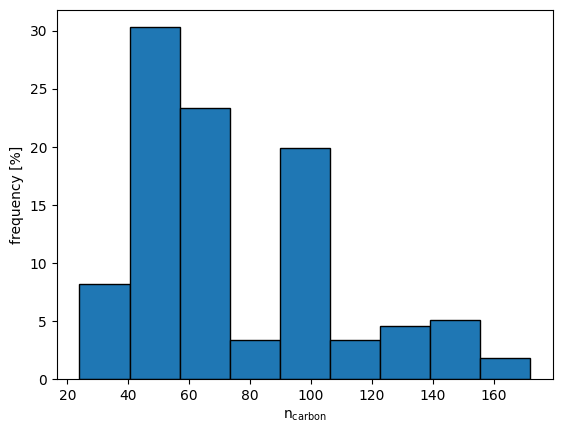

In [84]:
# Create plots.
sigma = obs.spectrum.uncertainty.array

fit.plot(
    wavelength=True,
    residual=True,
    # sigma=True,
    # save=True,
    # output=plotfile,
    # ftype='pdf',
)
fit.plot(
    wavelength=True,
    charge=True,
    # save=True,
    # output=plotfile,
    # ftype='pdf',
)
fit.plot(
    wavelength=True,
    size=True,
    # save=True,
    # output=plotfile,
    # ftype='pdf',
)
fit.plot(
    wavelength=True,
    composition=True,
    # save=True,
    # output=plotfile,
    # ftype='pdf',
)

fit.plot(sizedistribution=True)

---
### Exercise 3

1) Get the fit breakdown, load the previous fit pickle, and compare values.
2) Get the five most contributing PAHs in the new fit and compare with the previous fit.
3) Compare the 5 most contributing PAHs between the new and the previous fit.
---

Get new fit breakdown, load previous fit pickle, and compare.

In [85]:
# Get fit breakdown.
bd_new = fit.getbreakdown()

# Load previous fit breakdown pickle.
bd = pickle.load(open('PAHdb_PDRs4All_MIRI-MRS_APDR_Template_fit-breakdown.pkl', 'rb'))

# Print key, value pairs.
for k, v in bd_new.items():
    print(f'{k}: {v}')

print('\n')

for k, v in bd.items():
    print(f'{k}: {v}')

solo: 514
duo: 844
trio: 309
quartet: 84
quintet: 0
anion: 0.1790930669452243
neutral: 0.31884900698251395
cation: 0.5020579260722616
small: 0.24192772662458653
medium: 0.36698680572900055
large: 0.3910854676464127
nitrogen: 0.0
pure: 1.0
n_c: 73.90113151223922


solo: 305
duo: 528
trio: 279
quartet: 72
quintet: 0
anion: 0.18804148432349238
neutral: 0.28430442328472333
cation: 0.5276540923917843
small: 0.24392741095854314
medium: 0.3109815430055703
large: 0.4450910460358867
nitrogen: 0.0
pure: 1.0
n_c: 75.00241065842476


Compare the 5 most contributing PAHs between the new and the previous fit.

In [86]:
fp = fit.sort(flux=True)

new_uids = list(fp.keys())[:5]

print(top_uids)
print(new_uids)

[9578, 6328, 10542, 10550, 10823]
[9518, 6719, 10274, 6687, 4328]


In [87]:
# Get species and print properties
new_pahs = pahdb.getspeciesbyuid(new_uids)
new_pahs.print()

FORMULA   : C94H26+
CHARGE    : 1
SYMMETRY  : 2-A"
WEIGHT    : 1154.20345
TOTAL_E   : -3598.15212162
VIB_E     : 546.0317
METHOD    : UB3LYP
N_SOLO    : 10
N_DUO     : 16
N_TRIO    : 0
N_QUARTET : 0
N_QUINTET : 0
N_CH2     : 0
N_CHX     : 0
N_C       : 94
N_H       : 26
N_N       : 0
N_O       : 0
N_MG      : 0
N_SI      : 0
N_FE      : 0
COMMENT   : # b3lyp/6-31G* freq guess=check geom=check int=grid=ultrafine
FORMULA   : C60H20
CHARGE    : 0
SYMMETRY  : 1-A'
WEIGHT    : 740.1565
TOTAL_E   : -2298.79619082
VIB_E     : 371.4692
METHOD    : RB3LYP
N_SOLO    : 6
N_DUO     : 8
N_TRIO    : 6
N_QUARTET : 0
N_QUINTET : 0
N_CH2     : 0
N_CHX     : 0
N_C       : 60
N_H       : 20
N_N       : 0
N_O       : 0
N_MG      : 0
N_SI      : 0
N_FE      : 0
COMMENT   : # b3lyp/6-31G* freq guess=check geom=check int=grid=ultrafine
FORMULA   : C60H20+
CHARGE    : 1
SYMMETRY  : 2-A"
WEIGHT    : 740.1565
TOTAL_E   : -2298.60888391
VIB_E     : 372.3724
METHOD    : UB3LYP
N_SOLO    : 7
N_DUO     : 10
N_TRIO 

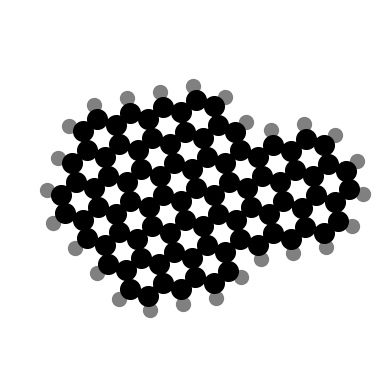

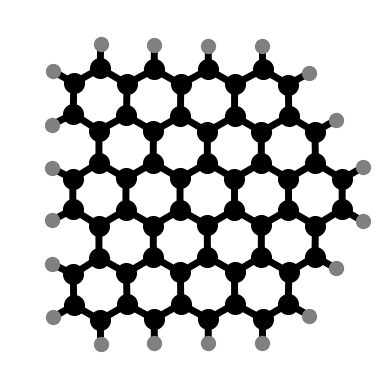

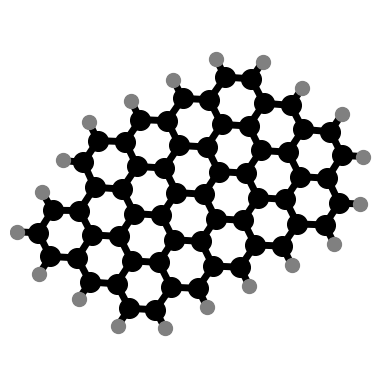

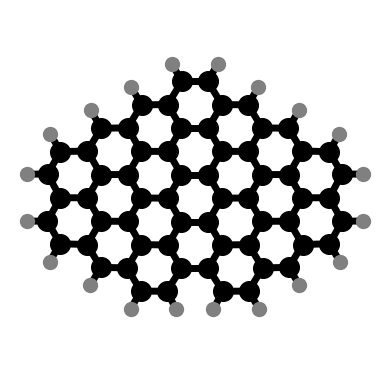

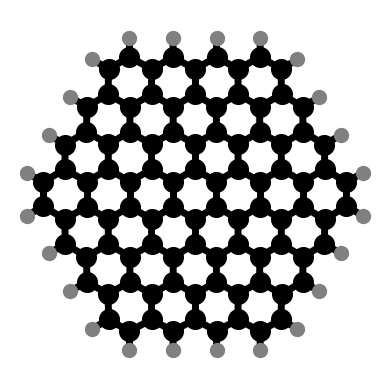

In [88]:
# Plot geometry
new_geometry = pahdb.getgeometrybyuid(new_uids)
new_geometry.diagonalize()
for uid in new_uids:
    new_geometry.plot(uid)